In [3]:
import pandas as pd
df = pd.read_csv('../data/smmh.csv')
df.columns.tolist()

['Timestamp',
 '1. What is your age?',
 '2. Gender',
 '3. Relationship Status',
 '4. Occupation Status',
 '5. What type of organizations are you affiliated with?',
 '6. Do you use social media?',
 '7. What social media platforms do you commonly use?',
 '8. What is the average time you spend on social media every day?',
 '9. How often do you find yourself using Social media without a specific purpose?',
 '10. How often do you get distracted by Social media when you are busy doing something?',
 "11. Do you feel restless if you haven't used Social media in a while?",
 '12. On a scale of 1 to 5, how easily distracted are you?',
 '13. On a scale of 1 to 5, how much are you bothered by worries?',
 '14. Do you find it difficult to concentrate on things?',
 '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
 '16. Following the previous question, how do you feel about these comparisons, generally speaking?',
 '17. How often do

In [4]:
all_opinions = df['16. Following the previous question, how do you feel about these comparisons, generally speaking?'].unique()
print("\n--- Unique Opinions on Social Media's Impact on Mental Health ---")    
print(all_opinions)


--- Unique Opinions on Social Media's Impact on Mental Health ---
[3 1 4 2 5]


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('../data/smmh.csv')

# 2. Define X-axis sorting order
time_order = [
    'Less than an Hour',
    'Between 1 and 2 hours',
    'Between 2 and 3 hours',
    'Between 3 and 4 hours',
    'Between 4 and 5 hours',
    'More than 5 hours'
]

# Convert column to Categorical to maintain logical order
df['8. What is the average time you spend on social media every day?'] = pd.Categorical(
    df['8. What is the average time you spend on social media every day?'],
    categories=time_order,
    ordered=True
)

# 3. Merge Q16 and Q17
q16 = '16. Following the previous question, how do you feel about these comparisons, generally speaking?'
q17 = '17. How often do you look to seek validation from features of social media?'
df['Q16_17_Merged'] = df[[q16, q17]].mean(axis=1)

# 4. Group by Screen Time and calculate means
grouped = df.groupby('8. What is the average time you spend on social media every day?').agg({
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?': 'mean',
    '13. On a scale of 1 to 5, how much are you bothered by worries?': 'mean',
    '18. How often do you feel depressed or down?': 'mean',
    '9. How often do you find yourself using Social media without a specific purpose?': 'mean',
    "11. Do you feel restless if you haven't used Social media in a while?": 'mean',
    '12. On a scale of 1 to 5, how easily distracted are you?': 'mean',
    '10. How often do you get distracted by Social media when you are busy doing something?': 'mean',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?': 'mean',
    '14. Do you find it difficult to concentrate on things?': 'mean',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?': 'mean',
    'Q16_17_Merged': 'mean'
}).reset_index()

# Calculate the grouped columns you requested
grouped['Group_Sleep'] = grouped['20. On a scale of 1 to 5, how often do you face issues regarding sleep?']
grouped['Group_MentalHealth'] = grouped[['13. On a scale of 1 to 5, how much are you bothered by worries?', '18. How often do you feel depressed or down?']].mean(axis=1)
grouped['Group_RestlessDistracted'] = grouped[['9. How often do you find yourself using Social media without a specific purpose?', "11. Do you feel restless if you haven't used Social media in a while?", '12. On a scale of 1 to 5, how easily distracted are you?']].mean(axis=1)
grouped['Group_Focus'] = grouped[['10. How often do you get distracted by Social media when you are busy doing something?', '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?']].mean(axis=1)

# Rename the time column for easier reading in the CSV
grouped.rename(columns={'8. What is the average time you spend on social media every day?': 'Screen Time'}, inplace=True)

# 5. Export to CSV
grouped.to_csv('../data/aggregated_screentime_trends.csv', index=False)

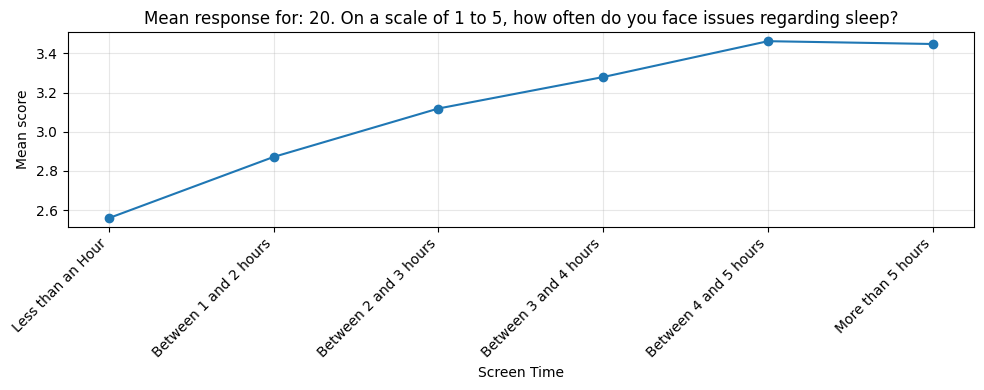

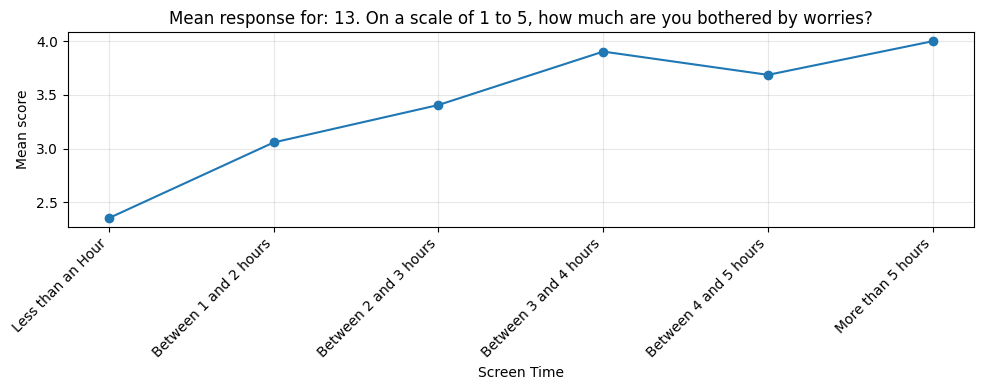

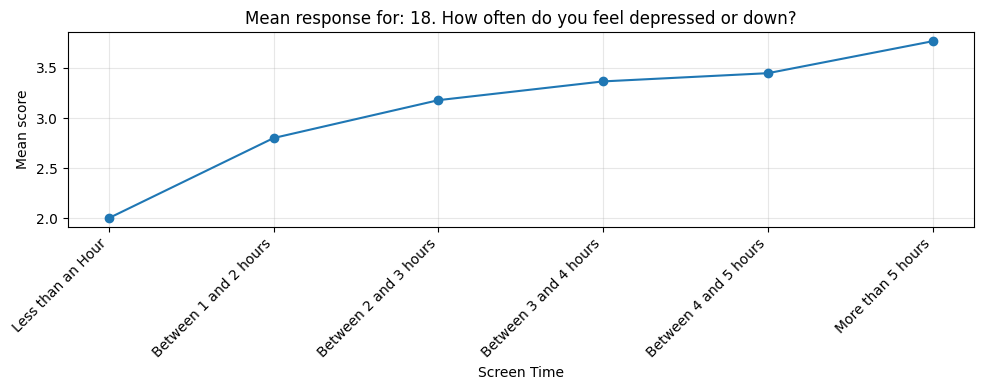

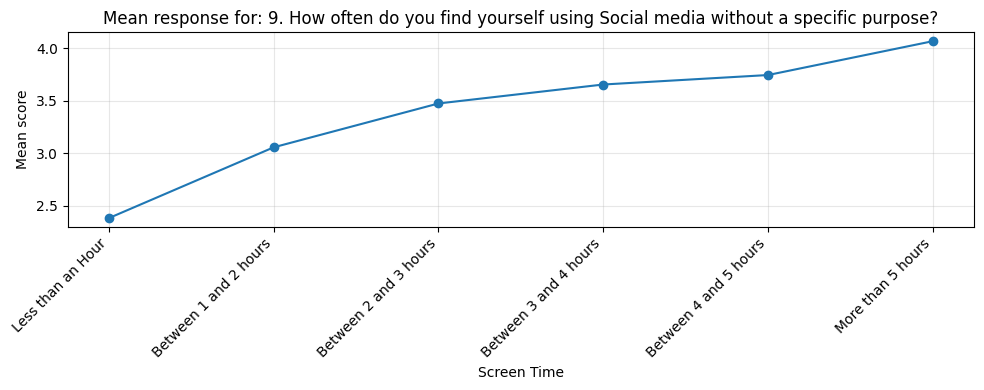

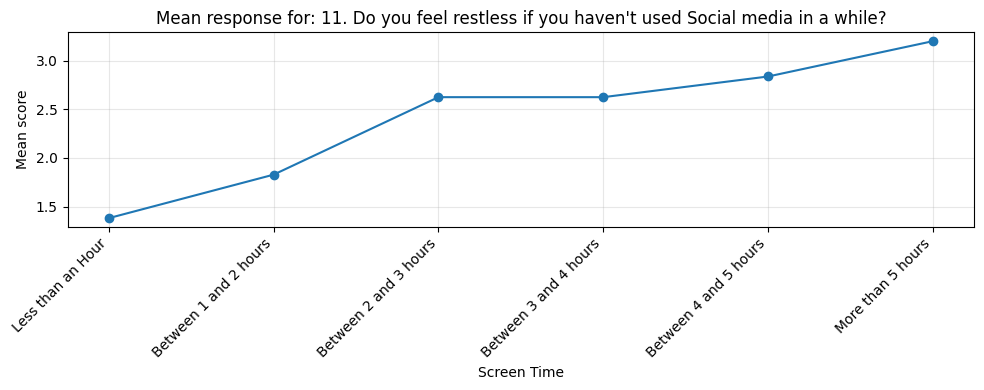

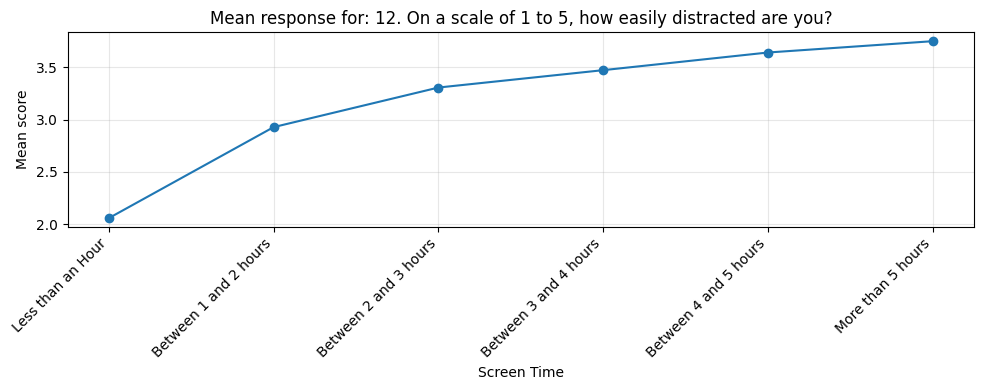

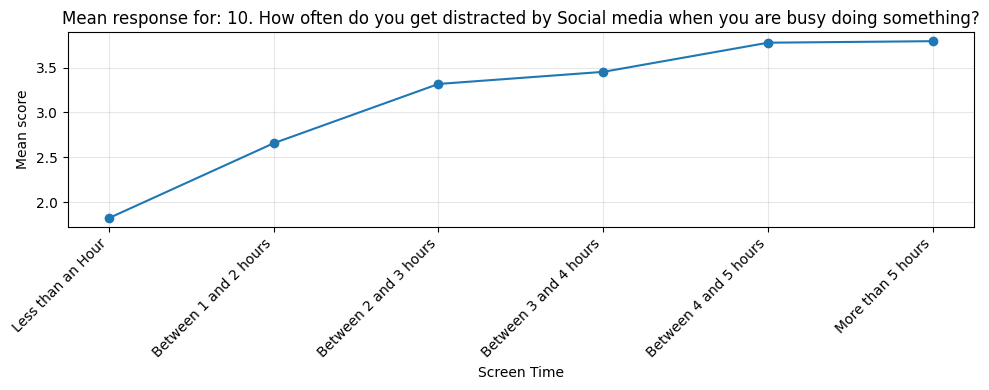

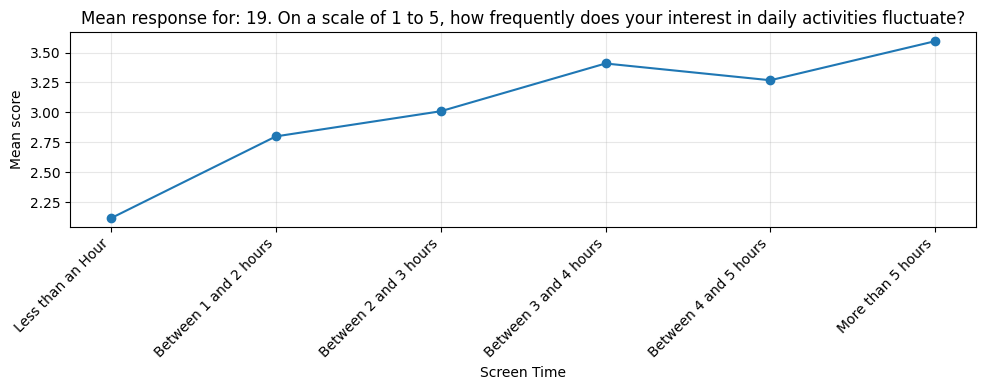

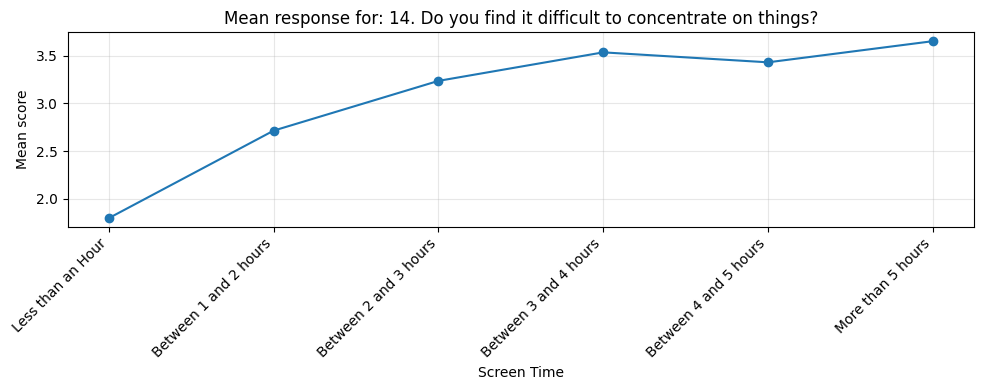

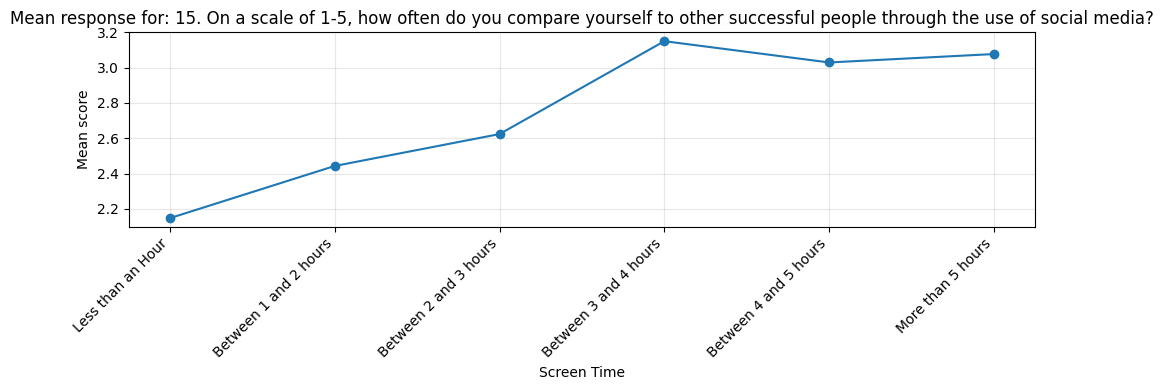

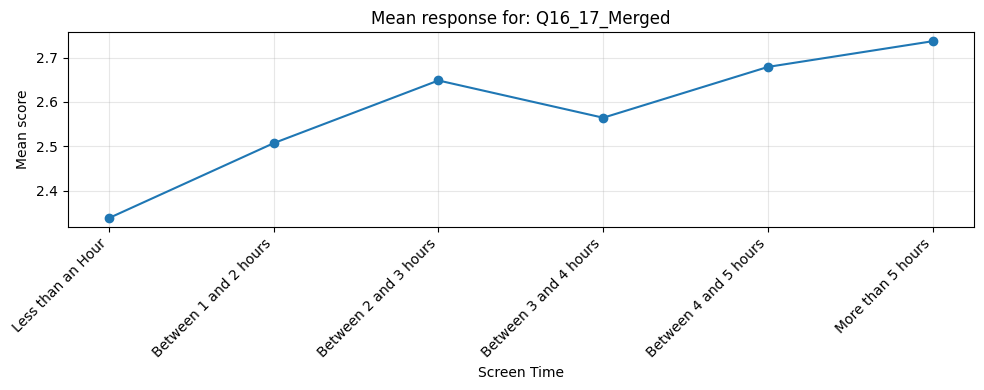

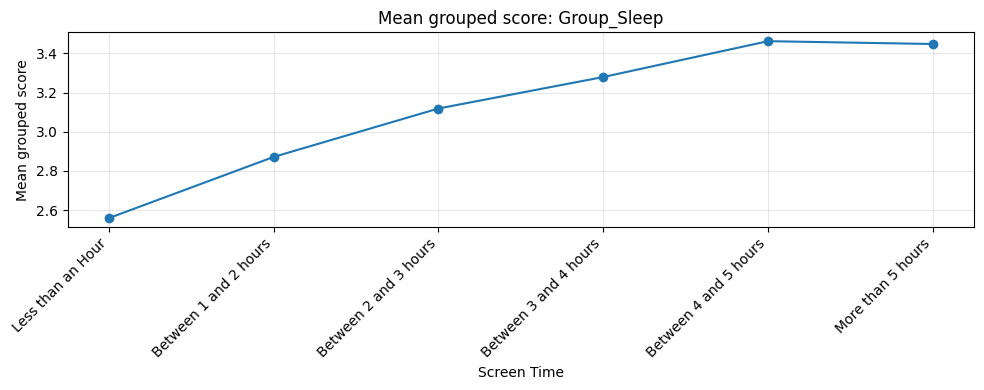

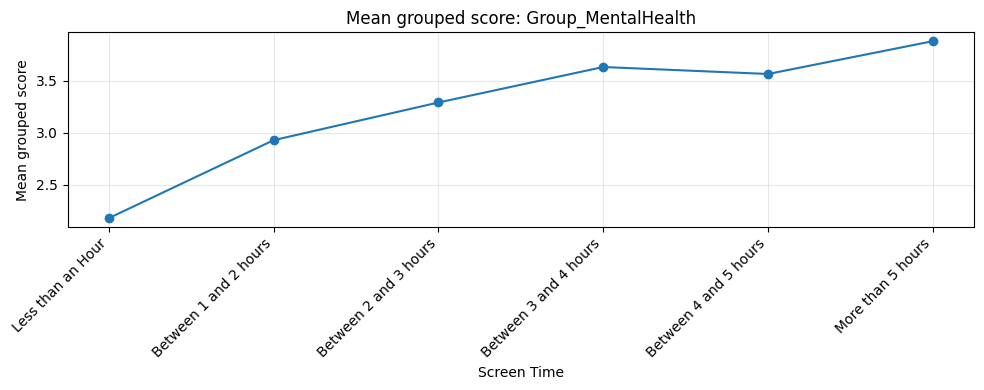

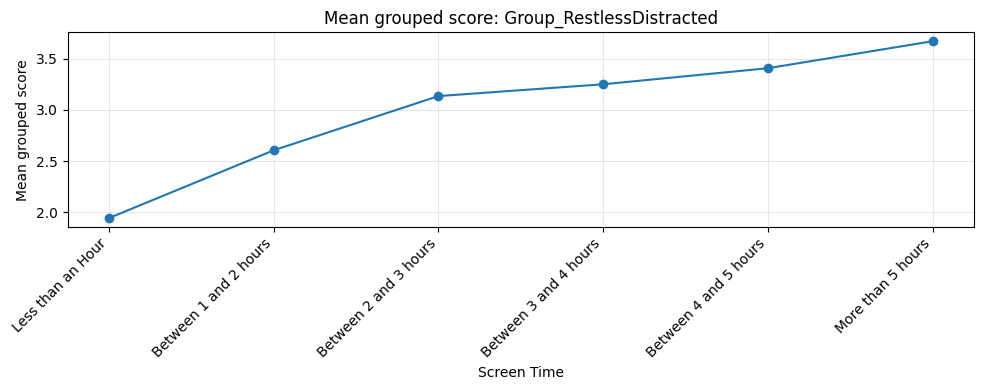

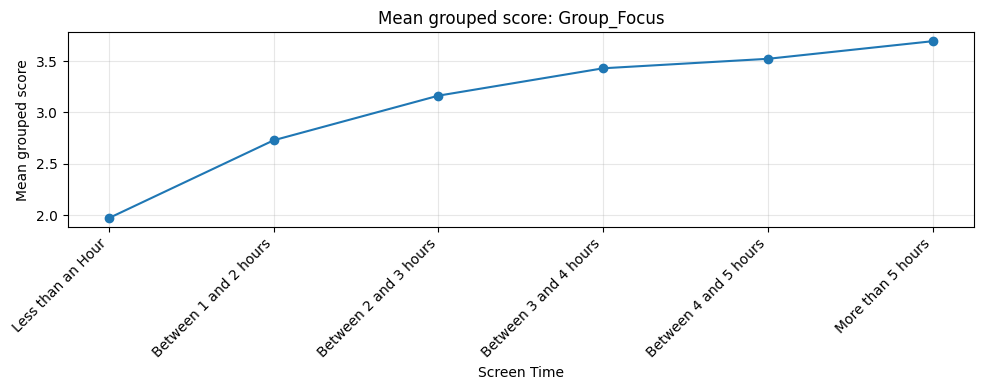

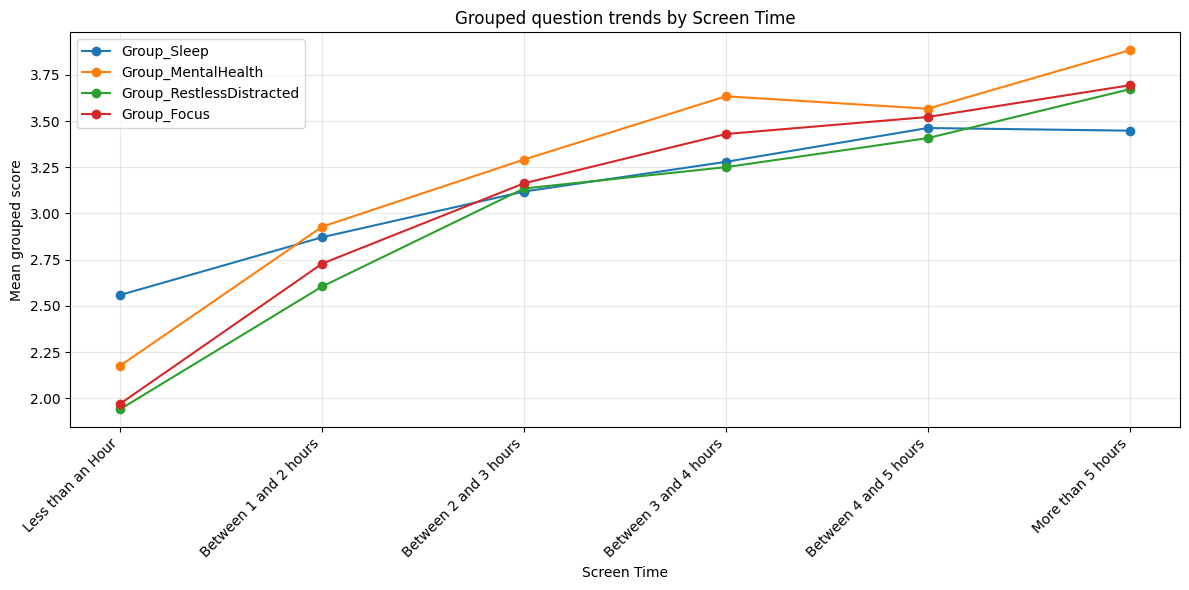

In [7]:
import matplotlib.pyplot as plt

# Plot individual question trends by screen time
question_columns = [
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?',
    '13. On a scale of 1 to 5, how much are you bothered by worries?',
    '18. How often do you feel depressed or down?',
    '9. How often do you find yourself using Social media without a specific purpose?',
    "11. Do you feel restless if you haven't used Social media in a while?",
    '12. On a scale of 1 to 5, how easily distracted are you?',
    '10. How often do you get distracted by Social media when you are busy doing something?',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?',
    '14. Do you find it difficult to concentrate on things?',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
    'Q16_17_Merged'
]

for col in question_columns:
    plt.figure(figsize=(10, 4))
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-')
    plt.title(f'Mean response for: {col}')
    plt.xlabel('Screen Time')
    plt.ylabel('Mean score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot grouped question trends by screen time
grouped_columns = ['Group_Sleep', 'Group_MentalHealth', 'Group_RestlessDistracted', 'Group_Focus']

for col in grouped_columns:
    plt.figure(figsize=(10, 4))
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-')
    plt.title(f'Mean grouped score: {col}')
    plt.xlabel('Screen Time')
    plt.ylabel('Mean grouped score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Combined grouped overview
plt.figure(figsize=(12, 6))
for col in grouped_columns:
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-', label=col)

plt.title('Grouped question trends by Screen Time')
plt.xlabel('Screen Time')
plt.ylabel('Mean grouped score')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


----

In [8]:
import pandas as pd
import numpy as np

# Load Data
df = pd.read_csv('../data/smmh.csv')

# Define X-axis sorting order
time_order = [
    'Less than an Hour',
    'Between 1 and 2 hours',
    'Between 2 and 3 hours',
    'Between 3 and 4 hours',
    'Between 4 and 5 hours',
    'More than 5 hours'
]

# Convert column to Categorical to maintain logical order
df['8. What is the average time you spend on social media every day?'] = pd.Categorical(
    df['8. What is the average time you spend on social media every day?'],
    categories=time_order,
    ordered=True
)

# Define question mappings for easier reference
questions = {
    'q9': '9. How often do you find yourself using Social media without a specific purpose?',
    'q10': '10. How often do you get distracted by Social media when you are busy doing something?',
    'q11': "11. Do you feel restless if you haven't used Social media in a while?",
    'q12': '12. On a scale of 1 to 5, how easily distracted are you?',
    'q13': '13. On a scale of 1 to 5, how much are you bothered by worries?',
    'q14': '14. Do you find it difficult to concentrate on things?',
    'q15': '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
    'q16': '16. Following the previous question, how do you feel about these comparisons, generally speaking?',
    'q17': '17. How often do you look to seek validation from features of social media?',
    'q18': '18. How often do you feel depressed or down?',
    'q19': '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?',
    'q20': '20. On a scale of 1 to 5, how often do you face issues regarding sleep?'
}

# Group by Screen Time and calculate means for ALL individual questions
agg_dict = {q: 'mean' for q in questions.values()}

grouped = df.groupby('8. What is the average time you spend on social media every day?').agg(agg_dict).reset_index()

# Rename columns to shorter versions for easier handling
for key, full_q in questions.items():
    grouped.rename(columns={full_q: key}, inplace=True)

# NEW LOGICAL GROUPINGS (4 categories)

# 1. ATTENTION & DISTRACTION - Questions about focus, distraction, purposeless use
grouped['Group_Attention'] = grouped[['q9', 'q10', 'q12', 'q14']].mean(axis=1)

# 2. EMOTIONAL WELLBEING - Questions about worry, depression, mood fluctuation
grouped['Group_Emotional'] = grouped[['q13', 'q18', 'q19']].mean(axis=1)

# 3. SOCIAL VALIDATION - Questions about comparison, validation seeking, comparison feelings
grouped['Group_SocialValidation'] = grouped[['q15', 'q16', 'q17']].mean(axis=1)

# 4. BEHAVIORAL DEPENDENCE - Questions about restlessness without social media and sleep issues
grouped['Group_Behavioral'] = grouped[['q11', 'q20']].mean(axis=1)

# Rename the time column for easier reading
grouped.rename(columns={'8. What is the average time you spend on social media every day?': 'Screen Time'}, inplace=True)

# Export to CSV
grouped.to_csv('../data/aggregated_screentime_trends_volume_2.csv', index=False)

print("✅ Data aggregation complete!")
print("\n📊 New Category Groupings:")
print("\n1. ATTENTION & DISTRACTION:")
print("   - Q9: Using social media without purpose")
print("   - Q10: Getting distracted by social media when busy")
print("   - Q12: How easily distracted")
print("   - Q14: Difficulty concentrating")

print("\n2. EMOTIONAL WELLBEING:")
print("   - Q13: Bothered by worries")
print("   - Q18: Feeling depressed or down")
print("   - Q19: Interest in daily activities fluctuates")

print("\n3. SOCIAL VALIDATION:")
print("   - Q15: Comparing to successful people")
print("   - Q16: Feelings about comparisons")
print("   - Q17: Seeking validation from social media")

print("\n4. BEHAVIORAL DEPENDENCE:")
print("   - Q11: Restless without social media")
print("   - Q20: Sleep issues")

print(f"\n📁 Output saved to: aggregated_screentime_trends_volume_2.csv")
print(f"📏 Shape: {grouped.shape}")
print("\n" + "="*60)
print(grouped.head())

✅ Data aggregation complete!

📊 New Category Groupings:

1. ATTENTION & DISTRACTION:
   - Q9: Using social media without purpose
   - Q10: Getting distracted by social media when busy
   - Q12: How easily distracted
   - Q14: Difficulty concentrating

2. EMOTIONAL WELLBEING:
   - Q13: Bothered by worries
   - Q18: Feeling depressed or down
   - Q19: Interest in daily activities fluctuates

3. SOCIAL VALIDATION:
   - Q15: Comparing to successful people
   - Q16: Feelings about comparisons
   - Q17: Seeking validation from social media

4. BEHAVIORAL DEPENDENCE:
   - Q11: Restless without social media
   - Q20: Sleep issues

📁 Output saved to: aggregated_screentime_trends_volume_2.csv
📏 Shape: (6, 17)

             Screen Time        q9       q10       q11       q12       q13  \
0      Less than an Hour  2.382353  1.823529  1.382353  2.058824  2.352941   
1  Between 1 and 2 hours  3.057143  2.657143  1.828571  2.928571  3.057143   
2  Between 2 and 3 hours  3.475248  3.316832  2.623762  

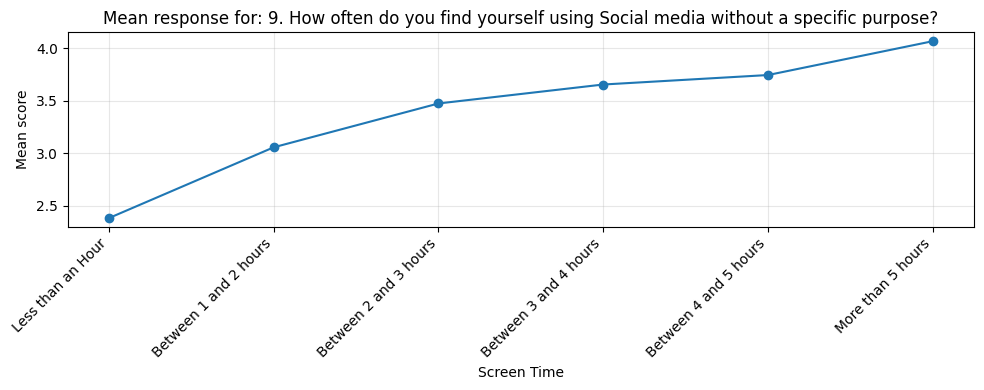

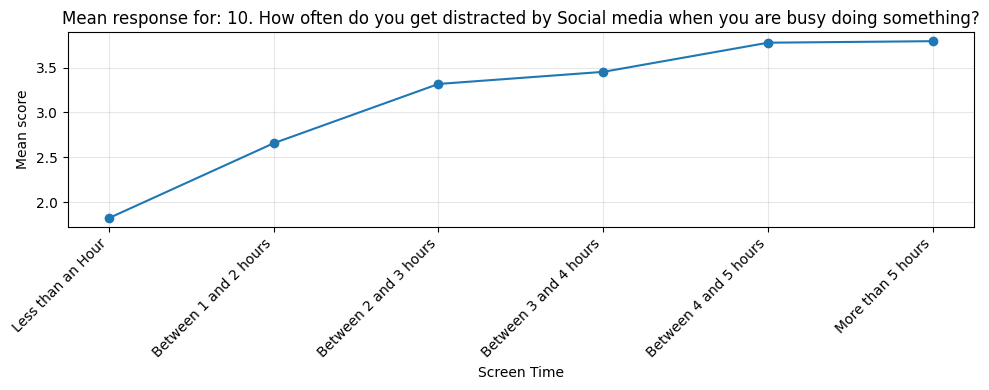

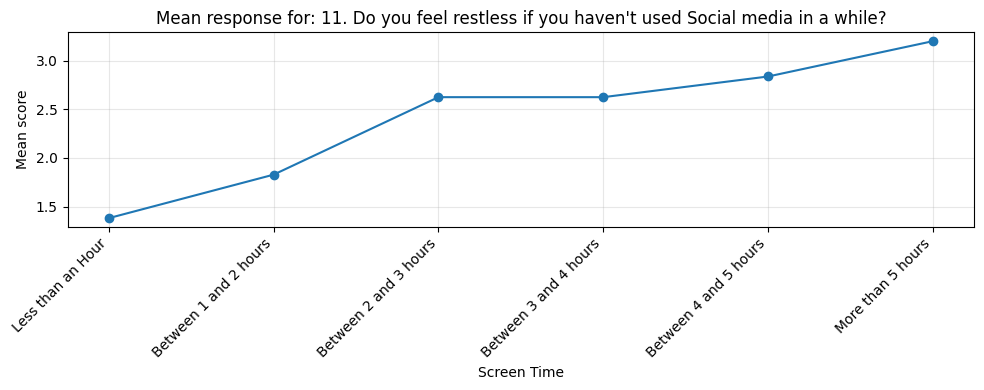

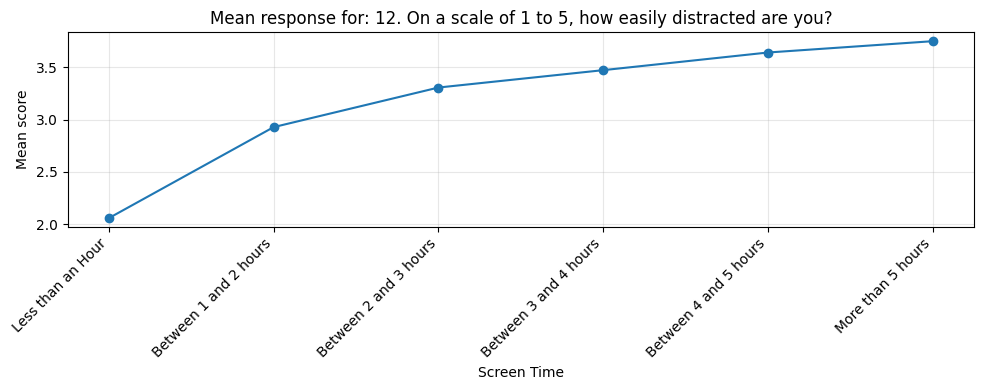

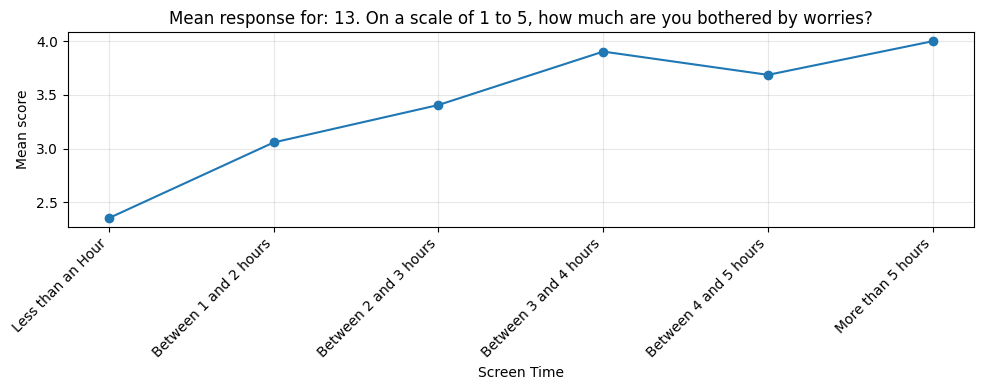

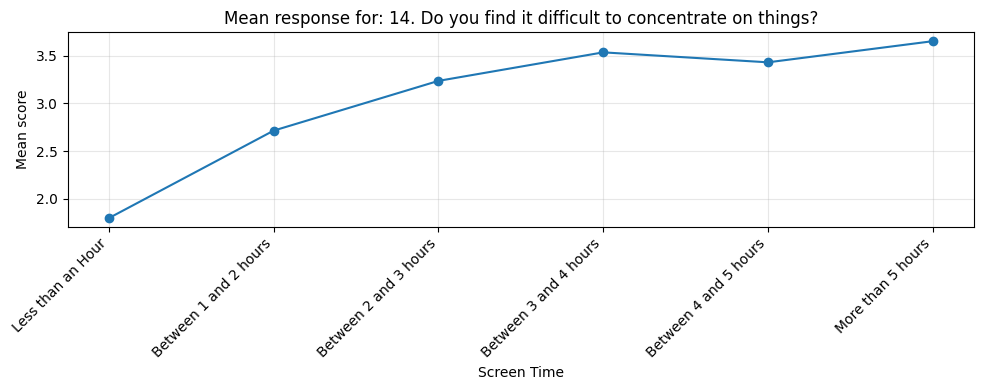

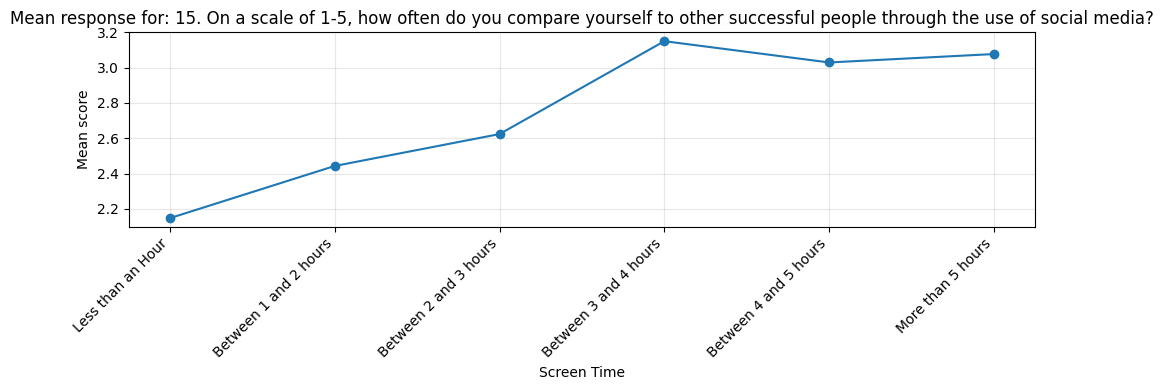

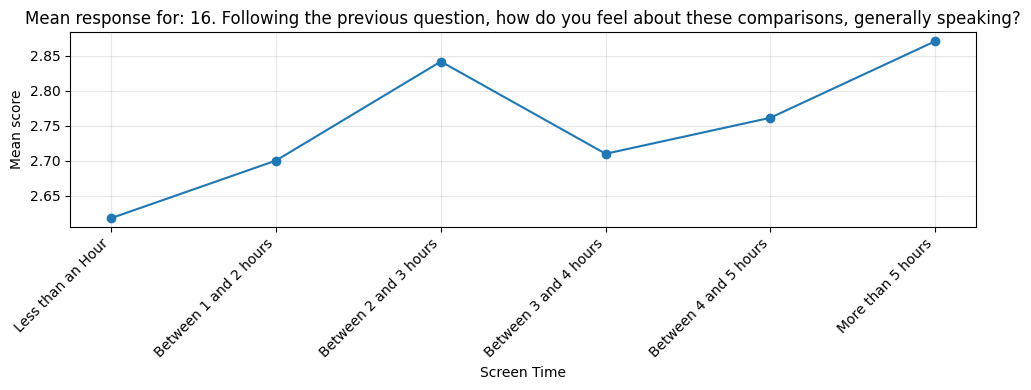

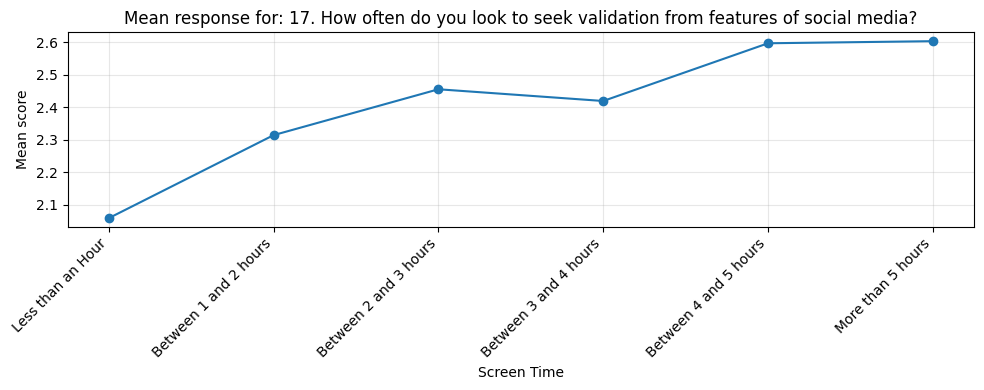

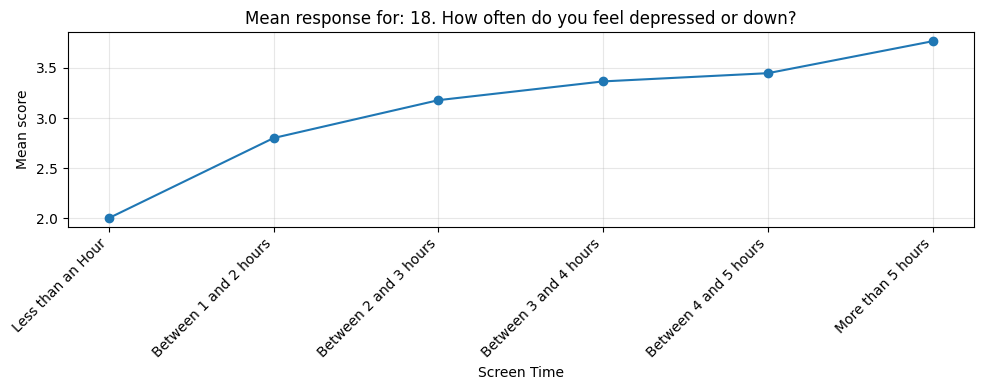

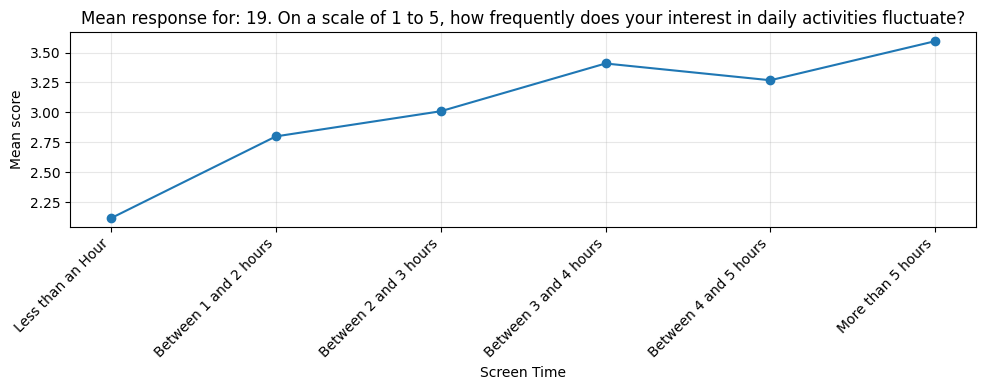

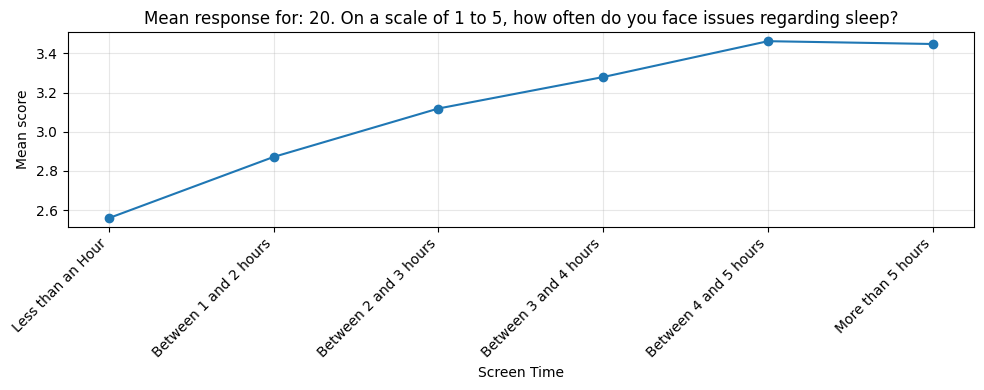

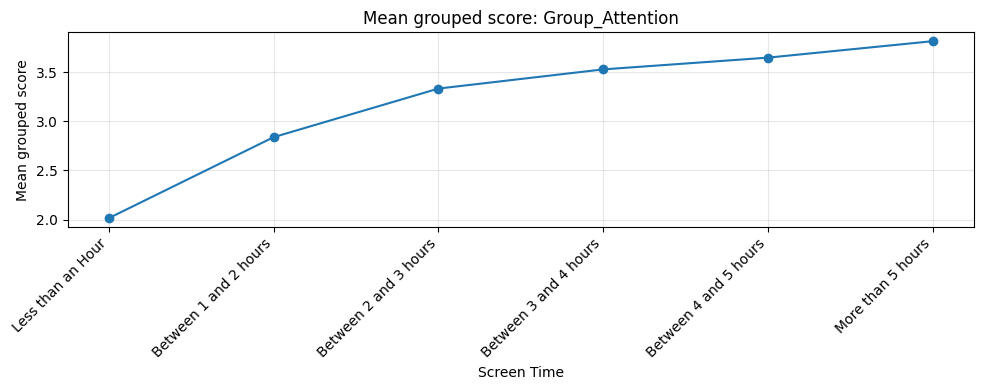

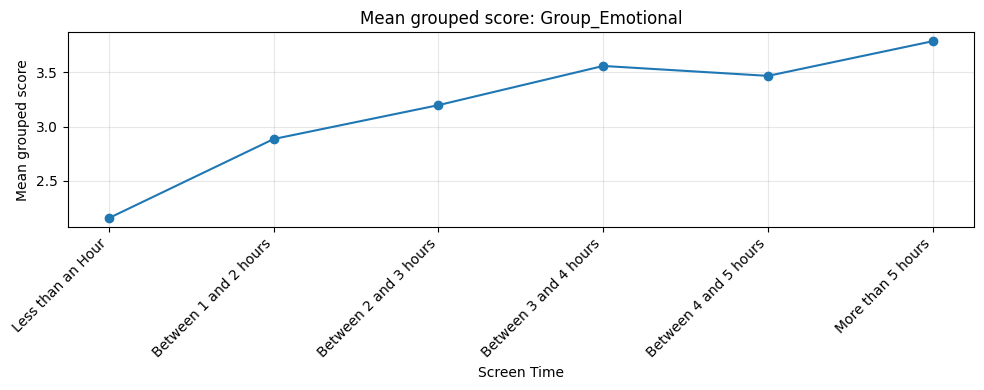

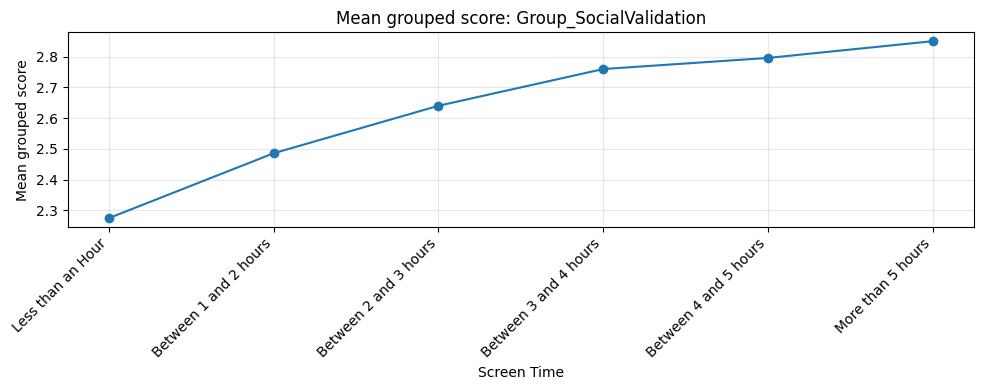

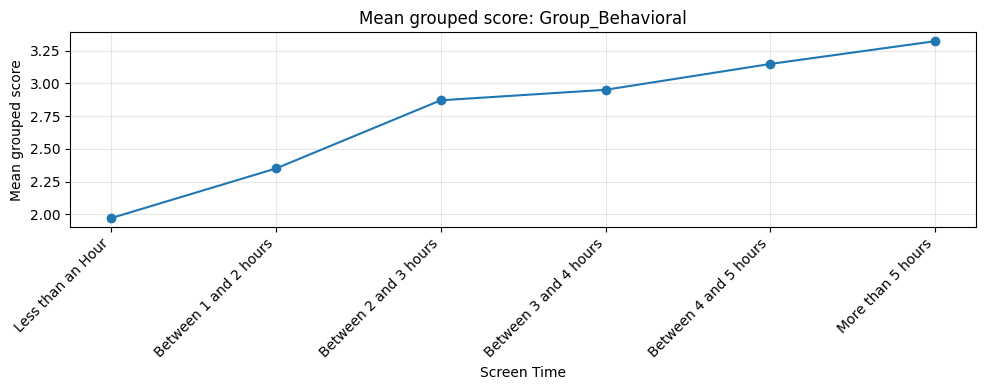

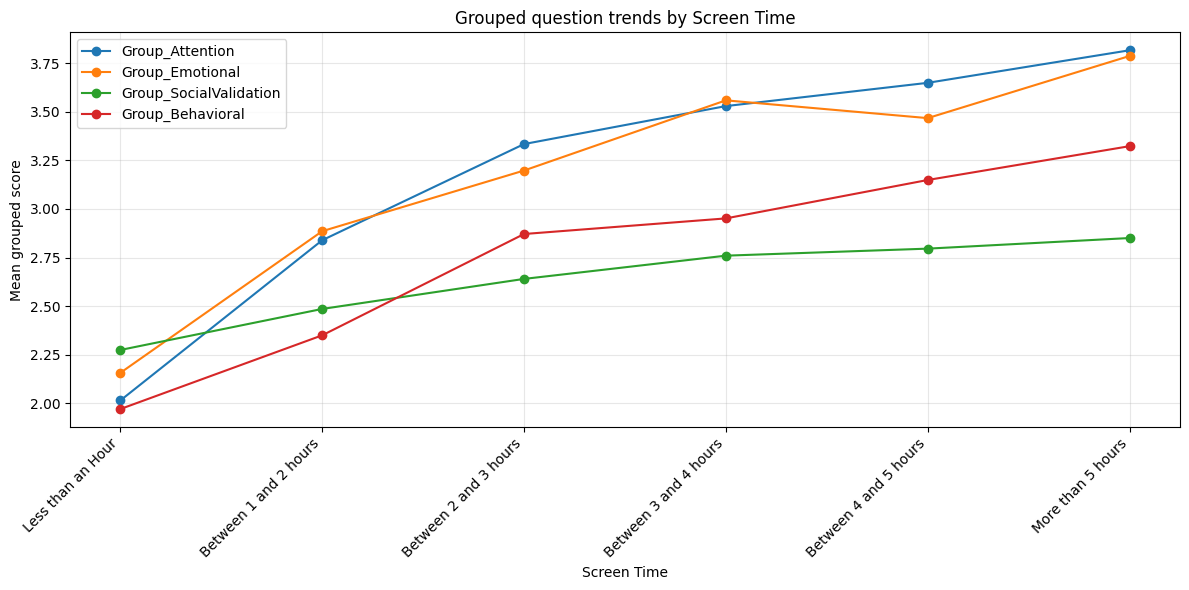

In [9]:
import matplotlib.pyplot as plt

# Plot individual question trends by screen time using the mapping from cell 6
question_columns = list(questions.keys())
question_labels = questions

for col in question_columns:
    plt.figure(figsize=(10, 4))
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-')
    plt.title(f"Mean response for: {question_labels[col]}")
    plt.xlabel('Screen Time')
    plt.ylabel('Mean score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot grouped question trends by screen time using the new mapped group names
grouped_columns = ['Group_Attention', 'Group_Emotional', 'Group_SocialValidation', 'Group_Behavioral']

for col in grouped_columns:
    plt.figure(figsize=(10, 4))
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-')
    plt.title(f'Mean grouped score: {col}')
    plt.xlabel('Screen Time')
    plt.ylabel('Mean grouped score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Combined grouped overview
plt.figure(figsize=(12, 6))
for col in grouped_columns:
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-', label=col)

plt.title('Grouped question trends by Screen Time')
plt.xlabel('Screen Time')
plt.ylabel('Mean grouped score')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
